# Deliverable 1: Chlorine backbone model
**Project:** Removed Is Not Safe · **Lead:** Partner A

**What this does:** you add bleach (chlorine) to water. This notebook predicts, minute by minute, how much chlorine is left, how much turns into chloramine if ammonia is present, and the "CT" disinfection number.

**What changed (Oct 4):** the chlorine equations and constants now live in one shared file, `chlorine_backbone.py`, in the repo's `ris/` folder. This notebook and the cipro notebook both import it, so they can never disagree. **To change a chlorine constant, edit `chlorine_backbone.py`** then re-run this notebook.

**How to use it:** change numbers only in the **KNOBS** box, then re-run all cells.

In [1]:
# Load tools + the model code from this repo (run from the repo root or notebooks/)
import sys, pathlib
root = pathlib.Path.cwd()
if not (root / "ris").exists():
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ris import chlorine_backbone as cb
print("Loaded.")

Loaded.


## Step 2: KNOBS (the settings you choose)

In [2]:
pH          = 7.5    # acidity of the water
Cl_dose_mgL = 5.0    # bleach dose, mg/L as Cl2 (typical wastewater: 2-10)
NH3_mgN_L   = 0.0    # ammonia already in the water, mg/L as N (try 0, 0.5, 2)
contact_min = 30     # how long the water stays in the chlorine tank, minutes

## Step 3: Unit conversion and speciation
Plants measure in mg/L; chemistry works in mol/L. Chlorine is two forms, **HOCl** (strong, does the reacting) and **OCl⁻** (weak); ammonia is **NH₄⁺** (doesn't react) and **NH₃** (reacts). pH sets the split.

In [3]:
Cl0, NH30 = cb.mgL_Cl2_to_M(Cl_dose_mgL), cb.mgN_L_to_M(NH3_mgN_L)
a_HOCl, a_NH3 = cb.speciation(pH)
print(f"Start: chlorine {Cl0:.2e} mol/L, ammonia {NH30:.2e} mol/L")
print(f"At pH {pH}: {a_HOCl:.0%} of chlorine is HOCl; {a_NH3:.1%} of ammonia is NH3")

Start: chlorine 7.05e-05 mol/L, ammonia 0.00e+00 mol/L
At pH 7.5: 52% of chlorine is HOCl; 1.7% of ammonia is NH3


## Step 4: Rate equations
The equations are in `chlorine_backbone.py` → `backbone_rates()`. The next box prints them so you can read them here. They track 4 things: free chlorine **FC**, total ammonia **TA**, monochloramine **MCA**, and **CT**:
- Chloramine forms at `k × [HOCl] × [NH3]`
- Organics eat chlorine at `k_demand × FC`
- CT grows at free chlorine (mg/L) per minute

In [4]:
import inspect
print(inspect.getsource(cb.backbone_rates))

def rates(t, y):
    FC, TA, MCA, CT = y
    d, _ = cb.backbone_rates(FC, TA, MCA, pH)
    return d

def backbone_rates(FC, TA, MCA, pH, c=CHLORINE):
    """
    How fast free chlorine, ammonia, chloramine and CT change RIGHT NOW,
    from chlorine chemistry alone (no ciprofloxacin).

    Returns
      d    : [dFC/dt, dTA/dt, dMCA/dt, dCT/dt]  (mol/L/s, except CT in mg*min/L per s)
      HOCl : concentration of HOCl right now, mol/L  (cipro model needs this)

    The cipro model calls this, then SUBTRACTS what cipro uses from dFC and dMCA.
    That subtraction is the two-way link: chlorine sets how fast cipro reacts,
    and cipro's reactions use up chlorine.
    """
    a_HOCl, a_NH3 = speciation(pH, c)
    HOCl = a_HOCl * FC                                    # reactive part of chlorine
    NH3 = a_NH3 * TA                                      # reactive part of ammonia

    r_chloramine = c["k_NH3_HOCl"] * HOCl * NH3           # HOCl + NH3 -> NH2Cl
    r_demand = c["k_demand"] * FC                         # chlorine eaten by organics

    dFC = -r_chloramine - r_demand
    dTA = -r

## Step 5: Solve (step through time)
`solve_ivp` takes many tiny time steps; **LSODA** stays stable when some reactions are very fast and others slow.

In [5]:
t_end = contact_min * 60
sol = solve_ivp(rates, [0, t_end], [Cl0, NH30, 0.0, 0.0], method="LSODA",
                t_eval=np.linspace(0, t_end, 400), rtol=1e-8, atol=1e-14)
print("Solver finished:", sol.success)
FC_mgL, MCA_mgL = cb.M_to_mgL_Cl2(sol.y[0]), cb.M_to_mgL_Cl2(sol.y[2])
print(f"After {contact_min} min: free chlorine {FC_mgL[-1]:.2f} mg/L, "
      f"chloramine {MCA_mgL[-1]:.2f} mg/L, CT {sol.y[3][-1]:.0f} mg·min/L")

Solver finished: True
After 30 min: free chlorine 3.49 mg/L, chloramine 0.00 mg/L, CT 126 mg·min/L


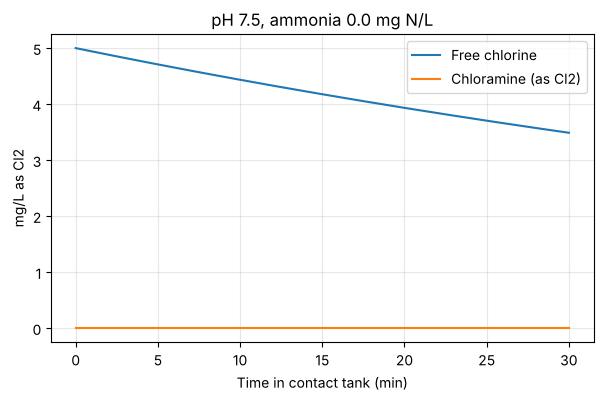

In [6]:
# STEP 6: Graph
plt.figure(figsize=(7, 4))
plt.plot(sol.t/60, FC_mgL, label="Free chlorine")
plt.plot(sol.t/60, MCA_mgL, label="Chloramine (as Cl2)")
plt.xlabel("Time in contact tank (min)"); plt.ylabel("mg/L as Cl2")
plt.title(f"pH {pH}, ammonia {NH3_mgN_L} mg N/L"); plt.legend(); plt.grid(alpha=0.3); plt.show()

In [7]:
# STEP 7: Sanity checks = the "done when" test
assert np.all(sol.y[:3] >= -1e-12), "A concentration went negative: check units or signs"
print("Check passed: nothing went negative.")
print("Now try: ammonia 0.5 and 2; pH 6.5 and 8.5. Explain what changes and why.")

Check passed: nothing went negative.
Now try: ammonia 0.5 and 2; pH 6.5 and 8.5. Explain what changes and why.


## To do
- [ ] Run ammonia 0 / 0.5 / 2 mg N/L and pH 6.5 / 7.5 / 8.5; save the graphs to `figures/`
- [ ] Write 3 sentences explaining the changes (use the word "speciation")
- [ ] Conservation check: set `k_demand` to 0 in `chlorine_backbone.py`; free chlorine + chloramine should stay equal to the dose
- [ ] Fit `k_demand` (placeholder) to published residual chlorine; later to your own DPD data